In [1]:
# # 1. KESKKONNA SEADISTAMINE

# %%
!git clone https://github.com/wazenmai/MIDI-BERT.git
%cd MIDI-BERT

!pip install miditoolkit==0.1.14 mido==1.2.10 numpy transformers seaborn matplotlib scikit-learn pandas tqdm music21

import sys
import os
import zipfile

if os.path.basename(os.getcwd()) != "MIDI-BERT":
    %cd MIDI-BERT
sys.path.append(os.getcwd())

!mkdir -p Data/CP_data/tmp
!mkdir -p data_creation/prepare_data/dict
!python data_creation/prepare_data/dict/make_dict.py

if os.path.exists('data_creation/prepare_data/dict/CP.pkl'):
    print("EDUKAS: Sõnastik CP.pkl on loodud!")
else:
    print("VIGA: Sõnastikku ei tekkinud.")

Cloning into 'MIDI-BERT'...
remote: Enumerating objects: 1258, done.
remote: Counting objects: 100% (392/392), done.
remote: Compressing objects: 100% (254/254), done.
remote: Total 1258 (delta 171), reused 344 (delta 134), pack-reused 866 (from 1)
Receiving objects: 100% (1258/1258), 125.78 MiB | 9.95 MiB/s, done.
Resolving deltas: 100% (619/619), done.
Updating files: 100% (164/164), done.
/content/MIDI-BERT
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.5 MB/s eta 0:00:00
  Created wheel for miditoolkit: filename=miditoolkit-0.1.14-py3-none-any.whl size=19508 sha256=42f533efa9d71d6d8fa24b73ea718eda231e3c57650c89970928597c9e72f39c
  Stored in directory: /root/.cache/pip/wheels/f0/6e/d3/005b67a60d4a610bc9de6a19f02d205e7ce19972725138fff4
Successfully built miditoolkit
{'Bar': {'Bar New': 0, 'Bar Continue': 1, 'Bar <PAD>': 2, 'Bar <MASK>': 3}, 'Position': {'Position 1/16': 0, 'Position 2/16': 1, 'Position 3/16': 2, 'Position 4/16': 3,

In [2]:
# # 2. MUDELI LAADIMINE
from google.colab import drive
import torch
import torch.nn as nn
import pickle
import numpy as np
from transformers import BertConfig
from data_creation.prepare_data.model import CP
from MidiBERT.model import MidiBert

np.int = int
drive.mount('/content/drive')

ckpt_path = '/content/drive/MyDrive/LÕPUTÖÖ/MidiBERT-Piano/CP/pretrain_model.ckpt'
dict_path = 'data_creation/prepare_data/dict/CP.pkl'

with open(dict_path, 'rb') as f:
    e2w, w2e = pickle.load(f)

config = BertConfig(
    max_position_embeddings=512,
    position_embedding_type='relative_key_query',
    hidden_size=768, num_attention_heads=12, num_hidden_layers=12,
    pad_token_id=0, output_attentions=True, attn_implementation="eager"
)
config._attn_implementation = "eager"

midibert_base = MidiBert(bertConfig=config, e2w=e2w, w2e=w2e)
print("Laen eeltreenitud kaalusid...")
checkpoint = torch.load(ckpt_path, map_location='cpu')
state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
clean_state_dict = {k.replace("module.", "").replace("midibert.", ""): v
                    for k, v in state_dict.items()}
midibert_base.load_state_dict(clean_state_dict, strict=False)
print("EDUKAS: Eeltreenitud MidiBERT on valmis!")

cp_model = CP(dict=dict_path)

Mounted at /content/drive
Laen eeltreenitud kaalusid...
EDUKAS: Eeltreenitud MidiBERT on valmis!


In [3]:
# # 3. KLASSIFIKAATORI ARHITEKTUUR (masked pooling)

# %%
class CombinedClassifier(nn.Module):
    """
    6-klassiline klassifikaator masked pooling'uga.
    Klassid: Eesti, Soome, Bach, Mozart, Chopin, Debussy
    """
    def __init__(self, pretrained_midibert, num_classes):
        super().__init__()
        self.midibert = pretrained_midibert
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_ids, attn_mask, return_attentions=False):
        embs = [self.midibert.word_emb[i](input_ids[..., i])
                for i, _ in enumerate(self.midibert.classes)]
        emb_linear = self.midibert.in_linear(torch.cat([*embs], dim=-1))

        outputs = self.midibert.bert(
            inputs_embeds=emb_linear, attention_mask=attn_mask,
            output_hidden_states=True, output_attentions=True
        )

        # Masked pooling — keskmista ainult mitte-padding tokenid
        hidden = outputs.last_hidden_state
        mask = attn_mask.unsqueeze(-1).float()
        summed = (hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        pooled_output = summed / counts

        logits = self.classifier(self.dropout(pooled_output))
        if return_attentions:
            return logits, outputs.attentions
        return logits


target_labels = ['Eesti', 'Soome', 'Bach', 'Mozart', 'Chopin', 'Debussy']
label_to_id = {name: i for i, name in enumerate(target_labels)}
print(f"Klassid: {target_labels}")

Klassid: ['Eesti', 'Soome', 'Bach', 'Mozart', 'Chopin', 'Debussy']


In [4]:
# # 4. RAHVAMUUSIKA ANDMETE ETTEVALMISTUS
# Eesti XML → MIDI konversioon, tempo normaliseerimine, tpb ühtlustamine

# %%
import music21 as m21
from music21 import bar
import miditoolkit
import glob, shutil, random, tempfile
from tqdm import tqdm
from collections import Counter, defaultdict

# --- 4.1 Kataloogid ---
estonian_src = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/eesti"
finnish_src = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/soome"
processed_root = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/processed"
os.makedirs(os.path.join(processed_root, "eesti"), exist_ok=True)
os.makedirs(os.path.join(processed_root, "soome"), exist_ok=True)


# --- 4.2 Abifunktsioonid ---
def convert_xml_to_midi(xml_path, midi_path):
    """XML → MIDI, time signature säilitamine."""
    try:
        score = m21.converter.parse(xml_path)
        score.write('midi', fp=midi_path)
        midi = miditoolkit.MidiFile(midi_path)
        if not midi.time_signature_changes:
            time_sigs = score.recurse().getElementsByClass('TimeSignature')
            if time_sigs:
                ts = time_sigs[0]
                midi.time_signature_changes = [
                    miditoolkit.TimeSignature(numerator=ts.numerator,
                                              denominator=ts.denominator, time=0)
                ]
                midi.dump(midi_path)
        return True
    except Exception as e:
        print(f"  [VIGA] {os.path.basename(xml_path)}: {e}")
        return False


def convert_with_repeat_strip(xml_path, midi_path):
    """Eemaldab kordusmärkused enne MIDI-kirjutamist."""
    try:
        score = m21.converter.parse(xml_path)
        for rb in list(score.recurse().getElementsByClass('RepeatBracket')):
            try:
                rb.activeSite.remove(rb)
            except:
                pass
        for measure in score.recurse().getElementsByClass('Measure'):
            for bl in list(measure.getElementsByClass(bar.Repeat)):
                try:
                    measure.remove(bl)
                except:
                    pass
            if isinstance(measure.leftBarline, bar.Repeat):
                measure.leftBarline = bar.Barline('regular')
            if isinstance(measure.rightBarline, bar.Repeat):
                measure.rightBarline = bar.Barline('regular')
        for el in list(score.recurse().getElementsByClass(
                ['RepeatExpression', 'DalSegno', 'DaCapo', 'Coda', 'Segno'])):
            try:
                el.activeSite.remove(el)
            except:
                pass
        score.write('midi', fp=midi_path)
        return True
    except Exception as e:
        print(f"  [IKKAGI VIGA] {os.path.basename(xml_path)}: {e}")
        return False


def normalize_tempo(midi_path, target_tempo=120):
    """Kõik failid 120 BPM."""
    try:
        midi = miditoolkit.MidiFile(midi_path)
        midi.tempo_changes = [miditoolkit.TempoChange(tempo=target_tempo, time=0)]
        midi.dump(midi_path)
        return True
    except:
        return False


def resample_ticks_per_beat(midi_path, target_tpb=480):
    """Skaleerib kõik tick-väärtused nii, et ticks_per_beat = target_tpb."""
    try:
        midi = miditoolkit.MidiFile(midi_path)
        old_tpb = midi.ticks_per_beat
        if old_tpb == target_tpb:
            return True
        scale = target_tpb / old_tpb
        for inst in midi.instruments:
            for note in inst.notes:
                note.start = int(round(note.start * scale))
                note.end = int(round(note.end * scale))
            for cc in inst.control_changes:
                cc.time = int(round(cc.time * scale))
            for pb in inst.pitch_bends:
                pb.time = int(round(pb.time * scale))
        for tc in midi.tempo_changes:
            tc.time = int(round(tc.time * scale))
        for ts in midi.time_signature_changes:
            ts.time = int(round(ts.time * scale))
        for ks in midi.key_signature_changes:
            ks.time = int(round(ks.time * scale))
        for marker in midi.markers:
            marker.time = int(round(marker.time * scale))
        midi.ticks_per_beat = target_tpb
        midi.dump(midi_path)
        return True
    except Exception as e:
        print(f"  [VIGA tpb] {os.path.basename(midi_path)}: {e}")
        return False


# --- 4.3 Eesti failide konversioon ---
estonian_files_raw = (
    glob.glob(os.path.join(estonian_src, "**", "*.xml"), recursive=True) +
    glob.glob(os.path.join(estonian_src, "**", "*.mxl"), recursive=True) +
    glob.glob(os.path.join(estonian_src, "**", "*.musicxml"), recursive=True) +
    glob.glob(os.path.join(estonian_src, "**", "*.mid"), recursive=True) +
    glob.glob(os.path.join(estonian_src, "**", "*.midi"), recursive=True))
print(f"Eesti lähtefaile: {len(estonian_files_raw)}")

success_e = 0
for f in tqdm(estonian_files_raw, desc="Eesti pipeline"):
    name = os.path.splitext(os.path.basename(f))[0] + ".mid"
    out = os.path.join(processed_root, "eesti", name)
    if f.lower().endswith(('.mid', '.midi')):
        shutil.copy(f, out)
        ok = True
    else:
        ok = convert_xml_to_midi(f, out)
    if ok and normalize_tempo(out):
        success_e += 1

# Paranda ebaõnnestunud XML-failid (repeat-strip)
estonian_out = os.path.join(processed_root, "eesti")
all_xml = (glob.glob(os.path.join(estonian_src, "**", "*.xml"), recursive=True) +
           glob.glob(os.path.join(estonian_src, "**", "*.mxl"), recursive=True) +
           glob.glob(os.path.join(estonian_src, "**", "*.musicxml"), recursive=True))
processed_names = {os.path.splitext(os.path.basename(f))[0]
                   for f in glob.glob(os.path.join(estonian_out, "*.mid"))}
missing = [f for f in all_xml
           if os.path.splitext(os.path.basename(f))[0] not in processed_names]
print(f"Puuduvaid Eesti faile (repeat-viga): {len(missing)}")

for f in tqdm(missing, desc="Parandan repeat-vigu"):
    name = os.path.splitext(os.path.basename(f))[0] + ".mid"
    out = os.path.join(estonian_out, name)
    if convert_with_repeat_strip(f, out):
        normalize_tempo(out)

# --- 4.4 Soome failide kopeerimine + tempo ---
finnish_files_raw = (
    glob.glob(os.path.join(finnish_src, "**", "*.mid"), recursive=True) +
    glob.glob(os.path.join(finnish_src, "**", "*.midi"), recursive=True))
print(f"\nSoome lähtefaile: {len(finnish_files_raw)}")

for f in tqdm(finnish_files_raw, desc="Soome pipeline"):
    name = os.path.splitext(os.path.basename(f))[0] + ".mid"
    out = os.path.join(processed_root, "soome", name)
    shutil.copy(f, out)
    normalize_tempo(out)

# --- 4.5 Ticks_per_beat ühtlustamine (480) ---
all_folk_files = (glob.glob(os.path.join(processed_root, "eesti", "*.mid")) +
                  glob.glob(os.path.join(processed_root, "soome", "*.mid")))
print(f"\nSkaleerin {len(all_folk_files)} rahvamuusika faili tpb=480...")
for f in tqdm(all_folk_files, desc="TPB fix"):
    resample_ticks_per_beat(f)

# Kontroll
total_e = len(glob.glob(os.path.join(processed_root, "eesti", "*.mid")))
total_s = len(glob.glob(os.path.join(processed_root, "soome", "*.mid")))
print(f"\nRahvamuusika valmis: Eesti {total_e}, Soome {total_s}")

Eesti lähtefaile: 77


Eesti pipeline:   5%|▌         | 4/77 [00:03<00:49,  1.48it/s]

  [VIGA] 17.xml: cannot expand Stream: badly formed repeats or repeat expressions


Eesti pipeline:  10%|█         | 8/77 [00:05<00:44,  1.55it/s]

  [VIGA] 14.xml: cannot expand Stream: badly formed repeats or repeat expressions


...


Soome lähtefaile: 702


Soome pipeline: 100%|██████████| 702/702 [03:27<00:00,  3.38it/s]



Skaleerin 779 rahvamuusika faili tpb=480...


TPB fix: 100%|██████████| 779/779 [00:20<00:00, 38.76it/s]


Rahvamuusika valmis: Eesti 77, Soome 702


In [5]:
# # 5. ATEPP ANDMETE ETTEVALMISTUS

# %%
import pandas as pd

atepp_zip_path = "/content/drive/MyDrive/LÕPUTÖÖ/ATEPP.zip"
atepp_extract_dir = "/content/drive/MyDrive/LÕPUTÖÖ/ATEPP_dataset"

if not os.path.exists(atepp_extract_dir):
    print(f"Pakin {atepp_zip_path} lahti...")
    with zipfile.ZipFile(atepp_zip_path, 'r') as zip_ref:
        zip_ref.extractall(atepp_extract_dir)
    print("ATEPP lahti pakitud!")
else:
    print("ATEPP juba lahti pakitud.")

csv_path = os.path.join(atepp_extract_dir, "ATEPP-metadata-1.2.csv")
df_atepp = pd.read_csv(csv_path)
df_atepp.columns = [col.lower() for col in df_atepp.columns]

# Indekseerime kõik MIDI failid kettalt
all_atepp_midis = glob.glob(os.path.join(atepp_extract_dir, "**", "*.mid"), recursive=True)
filename_to_path = {os.path.basename(p): p for p in all_atepp_midis}
print(f"ATEPP MIDI faile kettal: {len(filename_to_path)}")

# Filtreerime 4 heliloojat
atepp_composers = ['bach', 'mozart', 'chopin', 'debussy']
atepp_data = []

for _, row in df_atepp.iterrows():
    if pd.isna(row['composer']) or pd.isna(row['midi_path']):
        continue
    composer_name = str(row['composer']).lower()
    for target in atepp_composers:
        if target in composer_name:
            csv_filename = os.path.basename(str(row['midi_path']))
            if csv_filename in filename_to_path:
                atepp_data.append({
                    'composer': target.capitalize(),
                    'midi_path': filename_to_path[csv_filename]
                })
            break

df_atepp_filtered = pd.DataFrame(atepp_data)
print(f"\nATEPP lugu leitud: {len(df_atepp_filtered)}")
print(df_atepp_filtered['composer'].value_counts())

ATEPP juba lahti pakitud.
ATEPP MIDI faile kettal: 11699

ATEPP lugu leitud: 4182
composer
Chopin     1829
Bach       1318
Mozart      714
Debussy     321
Name: count, dtype: int64


In [6]:
# # 6. KOMBINEERITUD ANDMESTIKU KOKKUPANEK

# %%
MAX_LEN = 256              # Ühtne pikkus kõigile
MAX_SEGMENTS_PER_FILE = 6  # Rahvamuusika: piisav
MAX_SEGMENTS_ATEPP = 6     # ATEPP: sama piir, et mitte üle ujutada
PADDING_THRESHOLD = 0.7
SHIFT_RANGE = list(range(-5, 6))
MAX_FILES_PER_COMPOSER = 200  # ATEPP heliloojate piir

# --- 6.1 Rahvamuusika failid ---
estonian_processed = sorted(glob.glob(os.path.join(processed_root, "eesti", "*.mid")))
finnish_processed = sorted(glob.glob(os.path.join(processed_root, "soome", "*.mid")))

all_songs = []
song_id_counter = 0

for f in estonian_processed:
    all_songs.append({'path': f, 'label': label_to_id['Eesti'],
                      'song_id': song_id_counter, 'domain': 'folk'})
    song_id_counter += 1

for f in finnish_processed:
    all_songs.append({'path': f, 'label': label_to_id['Soome'],
                      'song_id': song_id_counter, 'domain': 'folk'})
    song_id_counter += 1

# --- 6.2 ATEPP failid (piiratud arv helilooja kohta) ---
random.seed(42)
for composer in ['Bach', 'Mozart', 'Chopin', 'Debussy']:
    composer_files = df_atepp_filtered[
        df_atepp_filtered['composer'] == composer]['midi_path'].tolist()
    n_files = min(MAX_FILES_PER_COMPOSER, len(composer_files))
    sampled = random.sample(composer_files, n_files)
    for f in sampled:
        all_songs.append({'path': f, 'label': label_to_id[composer],
                          'song_id': song_id_counter, 'domain': 'atepp'})
        song_id_counter += 1

all_paths = [s['path'] for s in all_songs]
all_labels = np.array([s['label'] for s in all_songs])
all_song_ids = np.array([s['song_id'] for s in all_songs])
all_domains = [s['domain'] for s in all_songs]

print(f"\nKombineeritud andmestik: {len(all_songs)} pala")
for i, name in enumerate(target_labels):
    print(f"  {name}: {(all_labels == i).sum()}")


Kombineeritud andmestik: 1579 pala
  Eesti: 77
  Soome: 702
  Bach: 200
  Mozart: 200
  Chopin: 200
  Debussy: 200


In [9]:
# # 7. ÜKS KORD TOKENISEERIMINE (kiirendab fold-tsüklit ~5x)
# Tokeniseerime kõik failid ühe korra ette. Augmenteeritud Eesti segmendid
# hoitakse eraldi — fold'is lisatakse need ainult treeningandmetele.
# Andmeleket ei teki, sest transponeeritud versioonidel on sama song_id
# ja fold'i jagamine toimub song_id järgi.

# %%
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


def transpose_midi_temp(midi_path, semitones):
    """Transponeerib MIDI ajutisse faili."""
    midi = miditoolkit.MidiFile(midi_path)
    for inst in midi.instruments:
        for note in inst.notes:
            note.pitch = max(0, min(127, note.pitch + semitones))
    tmp = tempfile.NamedTemporaryFile(suffix='.mid', delete=False)
    midi.dump(tmp.name)
    return tmp.name


def tokenize_file(midi_path, label, song_id, max_segments):
    """Tokeniseerib faili, filtreerib padding-raskeid segmente."""
    try:
        input_ids, _ = cp_model.prepare_data([midi_path], task='melody',
                                              max_len=MAX_LEN)
        out = []
        for seg in input_ids[:max_segments]:
            seg_arr = np.array(seg)
            padding_ratio = (seg_arr[:, 0] == 2).mean()
            if padding_ratio < PADDING_THRESHOLD:
                out.append((seg, label, song_id))
        return out
    except:
        return []


class CombinedDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seg, label, song_id = self.data[idx]
        input_tensor = torch.tensor(seg, dtype=torch.long)
        attn_mask = (input_tensor[:, 0] != 2).float()
        return input_tensor, attn_mask, torch.tensor(label, dtype=torch.long), song_id


# --- 7.1 Baas-tokeniseerimine (kõik palad, ilma augmentatsioonita) ---
print("Tokeniseerin kõik palad (üks kord)...")
base_segments_by_sid = {}  # song_id -> [(seg, label, song_id), ...]

for s in tqdm(all_songs, desc="Baas-tokeniseerimine"):
    path, label, sid, domain = s['path'], s['label'], s['song_id'], s['domain']
    max_seg = MAX_SEGMENTS_ATEPP if domain == 'atepp' else MAX_SEGMENTS_PER_FILE
    segs = tokenize_file(path, label, sid, max_seg)
    base_segments_by_sid[sid] = segs

total_base = sum(len(v) for v in base_segments_by_sid.values())
print(f"Baas-segmente kokku: {total_base}")

# --- 7.2 Eesti augmentatsioon (transponeeritud versioonid) ---
print("\nTokeniseerin Eesti augmentatsioonid...")
aug_segments_by_sid = {}  # song_id -> [(seg, label, song_id), ...]

estonian_songs = [s for s in all_songs if s['label'] == label_to_id['Eesti']]
for s in tqdm(estonian_songs, desc="Eesti augmentatsioon"):
    path, label, sid = s['path'], s['label'], s['song_id']
    aug_segs = []
    for shift in SHIFT_RANGE:
        if shift == 0:
            continue  # originaal on juba base_segments_by_sid-s
        tmp = transpose_midi_temp(path, shift)
        aug_segs.extend(tokenize_file(tmp, label, sid, MAX_SEGMENTS_PER_FILE))
        os.remove(tmp)
    aug_segments_by_sid[sid] = aug_segs

total_aug = sum(len(v) for v in aug_segments_by_sid.values())
print(f"Augmenteeritud Eesti segmente: {total_aug}")
print(f"\nKokku tokeniseeritud: {total_base + total_aug} segmenti")
print("Tokeniseerimine valmis! Fold-tsükkel kasutab nüüd ainult filtreid.")

Tokeniseerin kõik palad (üks kord)...


100%|██████████| 1/1 [00:00<00:00, 130.48it/s]

100%|██████████| 1/1 [00:00<00:00, 74.91it/s]

100%|██████████| 1/1 [00:00<00:00, 81.14it/s]

100%|██████████| 1/1 [00:00<00:00, 37.16it/s]

100%|██████████| 1/1 [00:00<00:00, 95.88it/s]

100%|██████████| 1/1 [00:00<00:00, 112.83it/s]

100%|██████████| 1/1 [00:00<00:00, 120.34it/s]

100%|██████████| 1/1 [00:00<00:00, 93.40it/s]

100%|██████████| 1/1 [00:00<00:00, 68.06it/s]

100%|██████████| 1/1 [00:00<00:00, 85.92it/s]

100%|██████████| 1/1 [00:00<00:00, 73.26it/s]

100%|██████████| 1/1 [00:00<00:00, 62.00it/s]

100%|██████████| 1/1 [00:00<00:00, 39.00it/s]

100%|██████████| 1/1 [00:00<00:00, 35.86it/s]

100%|██████████| 1/1 [00:00<00:00, 55.79it/s]

100%|██████████| 1/1 [00:00<00:00, 66.52it/s]

100%|██████████| 1/1 [00:00<00:00, 193.37it/s]

100%|██████████| 1/1 [00:00<00:00, 55.43it/s]

100%|██████████| 1/1 [00:00<00:00, 62.32it/s]

100%|██████████| 1/1 [00:00<00:00, 63.57it/s]

100%|██████████| 1/1 [00:00<00:00, 52.32it/s]

100%|████

Baas-segmente kokku: 4720

Tokeniseerin Eesti augmentatsioonid...


100%|██████████| 1/1 [00:00<00:00, 171.46it/s]

100%|██████████| 1/1 [00:00<00:00, 183.53it/s]

100%|██████████| 1/1 [00:00<00:00, 188.09it/s]

100%|██████████| 1/1 [00:00<00:00, 240.55it/s]

100%|██████████| 1/1 [00:00<00:00, 248.49it/s]

100%|██████████| 1/1 [00:00<00:00, 233.38it/s]

100%|██████████| 1/1 [00:00<00:00, 241.12it/s]

100%|██████████| 1/1 [00:00<00:00, 247.93it/s]

100%|██████████| 1/1 [00:00<00:00, 228.05it/s]

100%|██████████| 1/1 [00:00<00:00, 116.20it/s]

100%|██████████| 1/1 [00:00<00:00, 103.66it/s]

100%|██████████| 1/1 [00:00<00:00, 85.63it/s]

100%|██████████| 1/1 [00:00<00:00, 86.91it/s]

100%|██████████| 1/1 [00:00<00:00, 113.64it/s]

100%|██████████| 1/1 [00:00<00:00, 83.60it/s]

100%|██████████| 1/1 [00:00<00:00, 89.37it/s]

100%|██████████| 1/1 [00:00<00:00, 106.36it/s]

100%|██████████| 1/1 [00:00<00:00, 102.14it/s]

100%|██████████| 1/1 [00:00<00:00, 108.40it/s]

100%|██████████| 1/1 [00:00<00:00, 127.00it/s]

100%|██████████| 1/1 [00:00<00:00, 125.86it/

Augmenteeritud Eesti segmente: 550

Kokku tokeniseeritud: 5270 segmenti
Tokeniseerimine valmis! Fold-tsükkel kasutab nüüd ainult filtreid.


In [10]:
# # 8. STRATIFIED K-FOLD CV

# %%
import copy
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score,
                              classification_report, balanced_accuracy_score)

SEED = 43
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kasutan: {device}")

N_FOLDS = 5
EPOCHS_FROZEN = 12
EPOCHS_FT = 3
PATIENCE = 3

# Salvestame algse BERT-i kaalud
initial_state = copy.deepcopy(midibert_base.state_dict())

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)


def evaluate_segments(model, loader):
    model.eval()
    preds, lbls = [], []
    with torch.no_grad():
        for inp, mask, lab, _ in loader:
            out = model(inp.to(device), mask.to(device))
            preds.extend(torch.argmax(out, 1).cpu().numpy())
            lbls.extend(lab.numpy())
    return preds, lbls


def evaluate_songs(model, loader):
    """Pala-tasandi hindamine: keskmistame segmentide logitid."""
    model.eval()
    song_logits = defaultdict(list)
    song_lbls = {}
    with torch.no_grad():
        for inp, mask, lab, sid in loader:
            out = model(inp.to(device), mask.to(device))
            for i, s in enumerate(sid):
                s = int(s)
                song_logits[s].append(out[i].cpu().numpy())
                song_lbls[s] = int(lab[i])
    preds, lbls = [], []
    for s, lst in song_logits.items():
        preds.append(int(np.argmax(np.mean(lst, axis=0))))
        lbls.append(song_lbls[s])
    return preds, lbls


# --- FOLD TSÜKKEL ---
fold_results = []
all_preds_aggregate = []
all_labels_aggregate = []

for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {N_FOLDS}")
    print('='*70)

    # Train/valid split (stratified, ~85/15)
    trainval_labels = all_labels[trainval_idx]
    inner_skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42 + fold_idx)
    inner_split = next(inner_skf.split(trainval_idx, trainval_labels))
    train_idx = trainval_idx[inner_split[0]]
    valid_idx = trainval_idx[inner_split[1]]

    train_songs = [all_songs[i] for i in train_idx]
    valid_songs = [all_songs[i] for i in valid_idx]
    test_songs = [all_songs[i] for i in test_idx]

    train_sids = {s['song_id'] for s in train_songs}
    valid_sids = {s['song_id'] for s in valid_songs}
    test_sids = {s['song_id'] for s in test_songs}

    # Klasside jaotus
    train_labels_f = np.array([s['label'] for s in train_songs])
    valid_labels_f = np.array([s['label'] for s in valid_songs])
    test_labels_f = np.array([s['label'] for s in test_songs])

    print(f"Train palu: {len(train_songs)}")
    for i, name in enumerate(target_labels):
        print(f"  {name}: train={( train_labels_f == i).sum()}, "
              f"valid={(valid_labels_f == i).sum()}, "
              f"test={(test_labels_f == i).sum()}")

    # Segmentide filtreerimine eeltokeniseeritud andmetest (kiire!)
    train_data = []
    for sid in train_sids:
        train_data.extend(base_segments_by_sid.get(sid, []))
        train_data.extend(aug_segments_by_sid.get(sid, []))  # augmentatsioon ainult treeningus
    valid_data = []
    for sid in valid_sids:
        valid_data.extend(base_segments_by_sid.get(sid, []))
    test_data = []
    for sid in test_sids:
        test_data.extend(base_segments_by_sid.get(sid, []))

    print(f"Segmente — train: {len(train_data)}, valid: {len(valid_data)}, "
          f"test: {len(test_data)}")

    # Segmenditasandi klassjaotus
    seg_labels = [s[1] for s in train_data]
    class_counts = Counter(seg_labels)
    print("Train segmentide jaotus:")
    for cls_id, count in sorted(class_counts.items()):
        print(f"  {target_labels[cls_id]}: {count}")

    # WeightedRandomSampler — iga klass saab võrdse kaalu
    sample_weights = [1.0 / class_counts[l] for l in seg_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(seg_labels),
                                     replacement=True)

    train_loader = DataLoader(CombinedDataset(train_data), batch_size=8, sampler=sampler)
    valid_loader = DataLoader(CombinedDataset(valid_data), batch_size=8, shuffle=False)
    test_loader = DataLoader(CombinedDataset(test_data), batch_size=8, shuffle=False)

    # --- Värske mudel ---
    midibert_base.load_state_dict(initial_state)
    classifier_model = CombinedClassifier(midibert_base, len(target_labels)).to(device)

    # FAAS A: külmutatud BERT
    for p in classifier_model.midibert.parameters():
        p.requires_grad = False
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, classifier_model.parameters()),
        lr=1e-3, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    best_balacc = 0
    patience_counter = 0
    print(f"\n--- Külmutatud baas ({EPOCHS_FROZEN} epohhi max) ---")
    for epoch in range(EPOCHS_FROZEN):
        classifier_model.train()
        for inp, mask, lab, _ in train_loader:
            inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
            optimizer.zero_grad()
            out = classifier_model(inp, mask)
            loss = criterion(out, lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(classifier_model.parameters(), 1.0)
            optimizer.step()

        vp, vl = evaluate_segments(classifier_model, valid_loader)
        v_balacc = balanced_accuracy_score(vl, vp)
        if (epoch + 1) % 2 == 0:
            print(f"  Ep {epoch+1}: valid_BalAcc={v_balacc:.3f}")

        if v_balacc > best_balacc:
            best_balacc = v_balacc
            patience_counter = 0
            torch.save(classifier_model.state_dict(), f"best_fold{fold_idx}_frozen.pt")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Frozen early stop ep{epoch+1}, best BalAcc={best_balacc:.3f}")
                break

    classifier_model.load_state_dict(torch.load(f"best_fold{fold_idx}_frozen.pt"))

    # FAAS B: fine-tune viimane BERT kiht
    print(f"\n--- Fine-tune (1 kiht, lr 5e-6) ---")
    for p in classifier_model.parameters():
        p.requires_grad = False
    for p in classifier_model.classifier.parameters():
        p.requires_grad = True
    n_layers = len(classifier_model.midibert.bert.encoder.layer)
    for p in classifier_model.midibert.bert.encoder.layer[n_layers - 1].parameters():
        p.requires_grad = True

    bert_params = [p for n, p in classifier_model.named_parameters()
                   if 'midibert' in n and p.requires_grad]
    clf_params = [p for n, p in classifier_model.named_parameters()
                  if 'classifier' in n and p.requires_grad]
    optimizer_ft = torch.optim.AdamW([
        {'params': bert_params, 'lr': 5e-6},
        {'params': clf_params, 'lr': 5e-5}
    ], weight_decay=0.05)

    best_ft_balacc = best_balacc
    patience_counter = 0
    for epoch in range(EPOCHS_FT):
        classifier_model.train()
        for inp, mask, lab, _ in train_loader:
            inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
            optimizer_ft.zero_grad()
            out = classifier_model(inp, mask)
            loss = criterion(out, lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(classifier_model.parameters(), 1.0)
            optimizer_ft.step()

        vp, vl = evaluate_segments(classifier_model, valid_loader)
        v_balacc = balanced_accuracy_score(vl, vp)
        print(f"  FT Ep {epoch+1}: valid_BalAcc={v_balacc:.3f}")

        if v_balacc > best_ft_balacc:
            best_ft_balacc = v_balacc
            patience_counter = 0
            torch.save(classifier_model.state_dict(), f"best_fold{fold_idx}_ft.pt")
        else:
            patience_counter += 1
            if patience_counter >= 1:
                break

    if os.path.exists(f"best_fold{fold_idx}_ft.pt"):
        classifier_model.load_state_dict(torch.load(f"best_fold{fold_idx}_ft.pt"))

    # --- HINDAMINE ---
    print(f"\n--- Test fold {fold_idx + 1} ---")
    sp, sl = evaluate_songs(classifier_model, test_loader)
    fold_acc = accuracy_score(sl, sp)
    fold_balacc = balanced_accuracy_score(sl, sp)
    fold_f1 = f1_score(sl, sp, average='macro')

    per_class_recall = {}
    for i, name in enumerate(target_labels):
        n_true = sum(1 for l in sl if l == i)
        n_correct = sum(1 for p, l in zip(sp, sl) if l == i and p == i)
        per_class_recall[name] = n_correct / max(1, n_true)

    print(f"  Acc: {fold_acc:.3f} | BalAcc: {fold_balacc:.3f} | F1: {fold_f1:.3f}")
    for name, rec in per_class_recall.items():
        print(f"  {name} recall: {rec:.3f}")

    result = {
        'fold': fold_idx + 1,
        'acc': fold_acc,
        'balacc': fold_balacc,
        'f1': fold_f1,
    }
    result.update({f'{name}_recall': rec for name, rec in per_class_recall.items()})
    fold_results.append(result)
    all_preds_aggregate.extend(sp)
    all_labels_aggregate.extend(sl)

Kasutan: cuda

FOLD 1 / 5
Train palu: 1052
  Eesti: train=50, valid=11, test=16
  Soome: train=469, valid=93, test=140
  Bach: train=133, valid=27, test=40
  Mozart: train=133, valid=27, test=40
  Chopin: train=134, valid=26, test=40
  Debussy: train=133, valid=27, test=40
Segmente — train: 3500, valid: 641, test: 949
Train segmentide jaotus:
  Eesti: 407
  Soome: 340
  Bach: 565
  Mozart: 794
  Chopin: 681
  Debussy: 713

--- Külmutatud baas (12 epohhi max) ---
  Ep 2: valid_BalAcc=0.684
  Ep 4: valid_BalAcc=0.666
  Ep 6: valid_BalAcc=0.701
  Frozen early stop ep6, best BalAcc=0.704

--- Fine-tune (1 kiht, lr 5e-6) ---
  FT Ep 1: valid_BalAcc=0.695

--- Test fold 1 ---
  Acc: 0.829 | BalAcc: 0.764 | F1: 0.752
  Eesti recall: 0.400
  Soome recall: 0.882
  Bach recall: 0.850
  Mozart recall: 0.950
  Chopin recall: 0.650
  Debussy recall: 0.850

FOLD 2 / 5
Train palu: 1052
  Eesti: train=50, valid=11, test=16
  Soome: train=469, valid=93, test=140
  Bach: train=133, valid=27, test=40
  M


6-KLASSI K-FOLD CV LÕPLIKUD TULEMUSED

--- Iga fold ---
 fold      acc   balacc       f1  Eesti_recall  Soome_recall  Bach_recall  Mozart_recall  Chopin_recall  Debussy_recall
    1 0.828897 0.763620 0.752458      0.400000      0.881720        0.850          0.950          0.650           0.850
    2 0.863281 0.809496 0.800655      0.500000      0.906977        0.875          0.925          0.750           0.900
    3 0.843284 0.792112 0.780885      0.545455      0.907216        0.925          0.675          0.875           0.825
    4 0.889706 0.840208 0.832298      0.545455      0.920792        0.900          1.000          0.800           0.875
    5 0.817518 0.748938 0.744234      0.416667      0.901961        0.750          0.925          0.725           0.775

--- KESKMINE ± HÄLVE ---
Accuracy:     0.849 ± 0.029
Balanced Acc: 0.791 ± 0.036
Macro F1:     0.782 ± 0.036
Eesti recall:  0.482 ± 0.070
Soome recall:  0.904 ± 0.014
Bach recall:  0.860 ± 0.068
Mozart recall:  0.895 ± 0.1

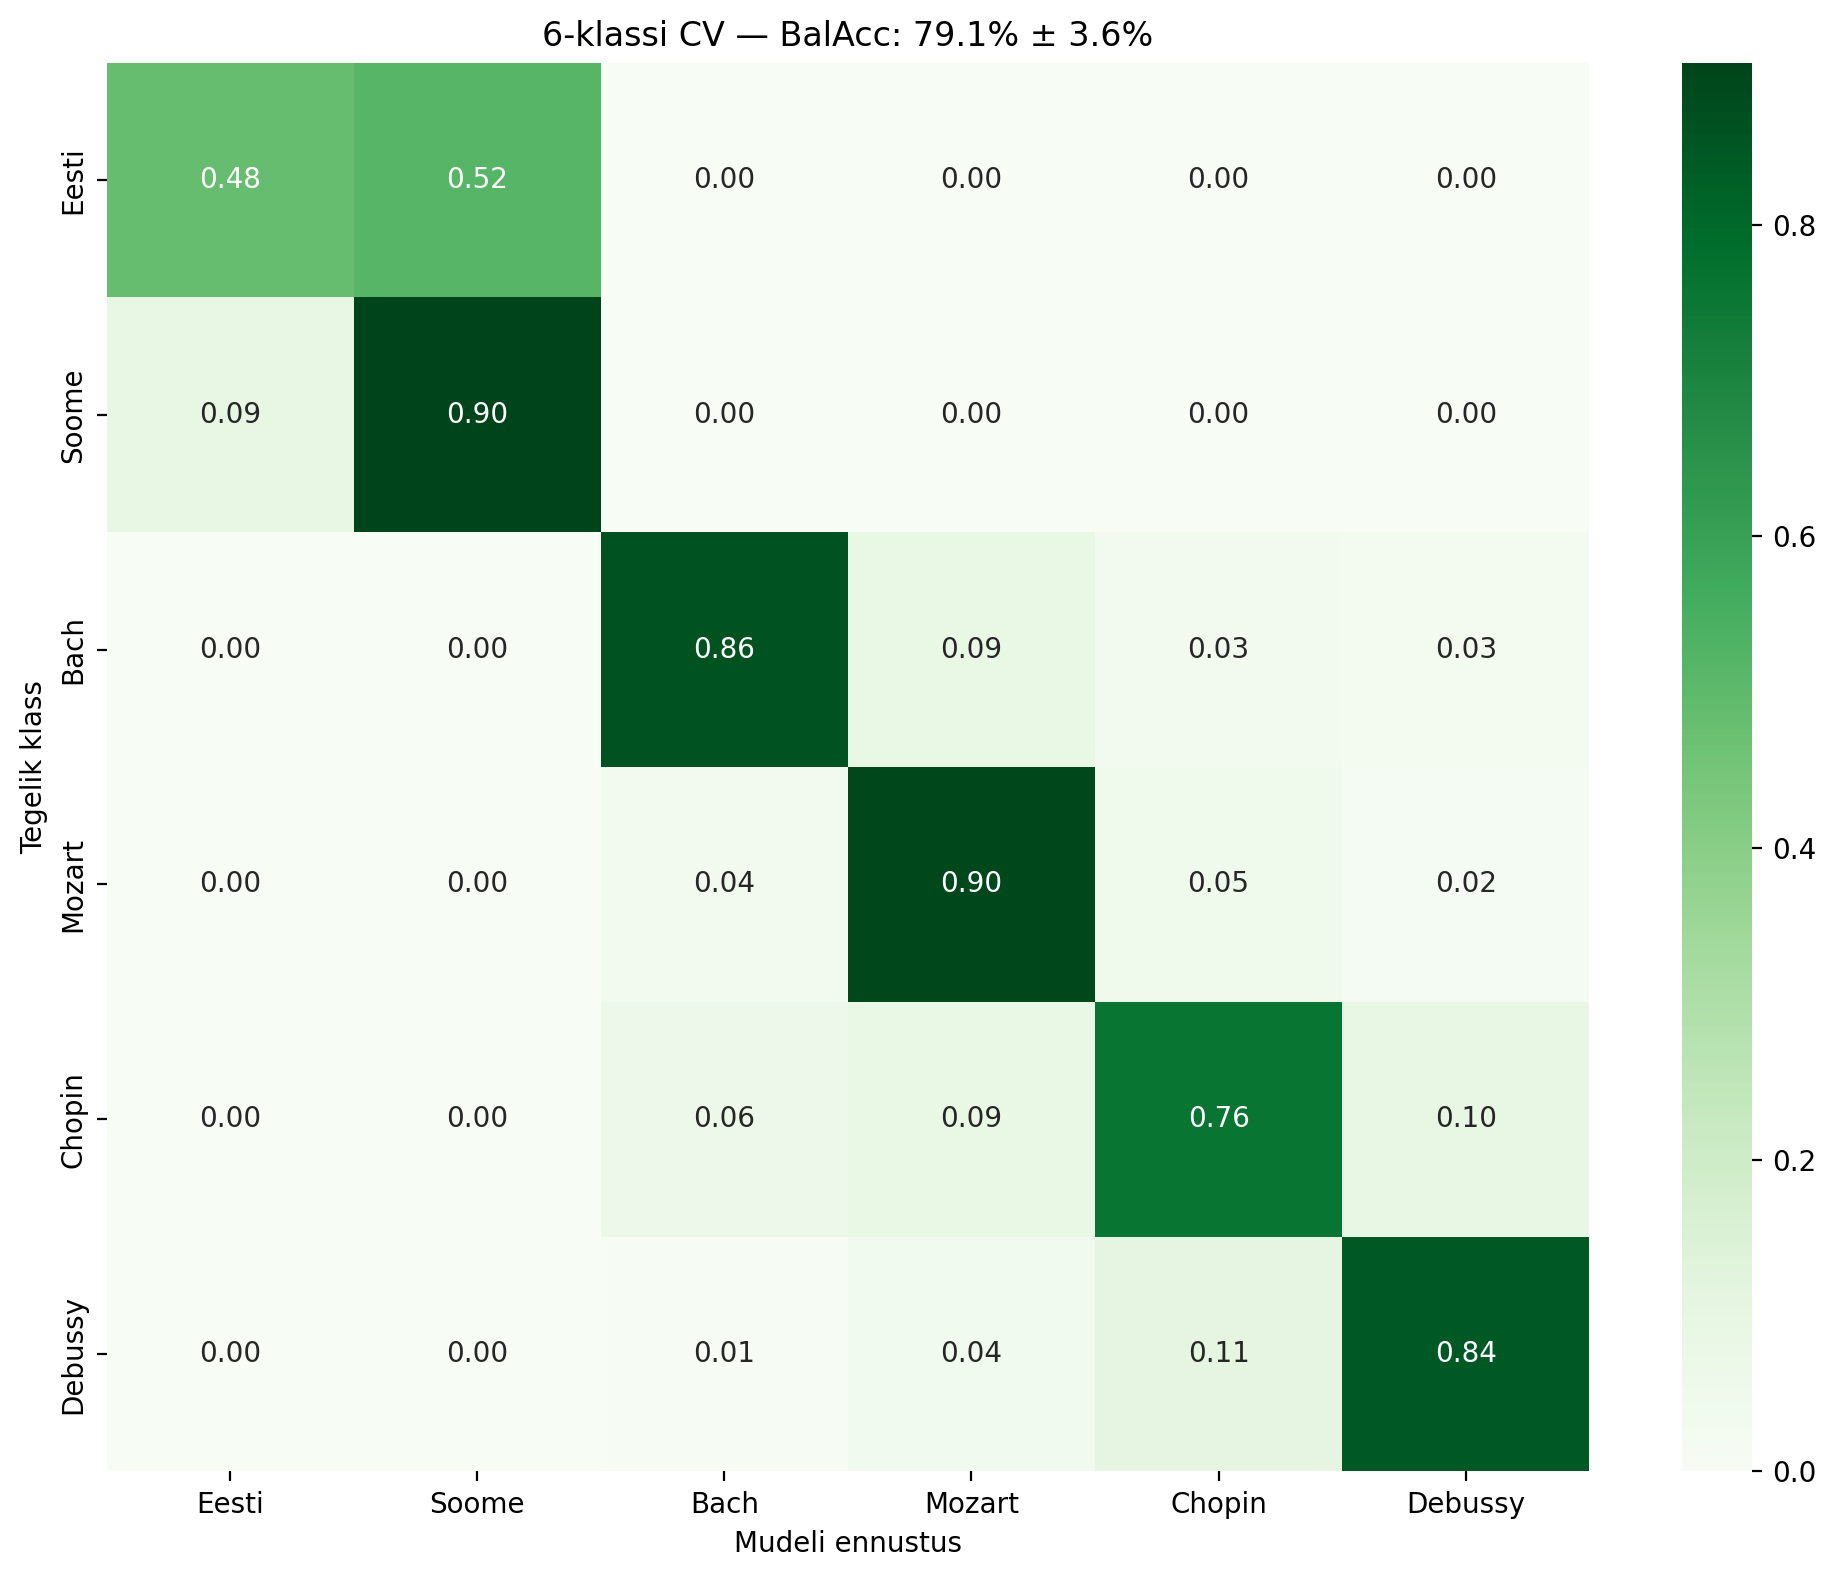

Tulemused salvestatud!


In [11]:
# # 9. KOKKUVÕTE JA VISUALISEERIMINE

# %%
print("\n" + "="*70)
print("6-KLASSI K-FOLD CV LÕPLIKUD TULEMUSED")
print("="*70)

df_results = pd.DataFrame(fold_results)
print("\n--- Iga fold ---")
print(df_results.to_string(index=False))

print("\n--- KESKMINE ± HÄLVE ---")
print(f"Accuracy:     {df_results['acc'].mean():.3f} ± {df_results['acc'].std():.3f}")
print(f"Balanced Acc: {df_results['balacc'].mean():.3f} ± {df_results['balacc'].std():.3f}")
print(f"Macro F1:     {df_results['f1'].mean():.3f} ± {df_results['f1'].std():.3f}")
for name in target_labels:
    col = f'{name}_recall'
    if col in df_results.columns:
        print(f"{name} recall:  {df_results[col].mean():.3f} ± {df_results[col].std():.3f}")

# Aggregeeritud classification report
print("\n--- KOGU CV AGGREGEERITUD ---")
print(classification_report(all_labels_aggregate, all_preds_aggregate,
                              target_names=target_labels, digits=3))

# Confusion matrix
cm = confusion_matrix(all_labels_aggregate, all_preds_aggregate)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=target_labels, yticklabels=target_labels)
plt.ylabel('Tegelik klass')
plt.xlabel('Mudeli ennustus')
plt.title(f'6-klassi CV — BalAcc: {df_results["balacc"].mean()*100:.1f}%'
          f' ± {df_results["balacc"].std()*100:.1f}%')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LÕPUTÖÖ/6klassi_cv_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Salvesta tulemused
df_results.to_csv('/content/drive/MyDrive/LÕPUTÖÖ/6klassi_cv_results.csv', index=False)
print("Tulemused salvestatud!")

In [12]:
# # 10. LÕPLIK MUDEL KOGU ANDMESTIKUL (attention rollout jaoks)

# %%
print("Treenin lõpliku mudeli kogu andmestikul...")

# Kõik segmendid (baas + augmentatsioon)
all_segments = []
for sid, segs in base_segments_by_sid.items():
    all_segments.extend(segs)
for sid, segs in aug_segments_by_sid.items():
    all_segments.extend(segs)
print(f"Segmente kokku: {len(all_segments)}")

seg_labels_all = [s[1] for s in all_segments]
class_counts_all = Counter(seg_labels_all)
print("Segmentide jaotus:")
for cls_id, count in sorted(class_counts_all.items()):
    print(f"  {target_labels[cls_id]}: {count}")

sw = [1.0 / class_counts_all[l] for l in seg_labels_all]
sampler_full = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True)
full_loader = DataLoader(CombinedDataset(all_segments), batch_size=8, sampler=sampler_full)

# Värske mudel
midibert_base.load_state_dict(initial_state)
final_model = CombinedClassifier(midibert_base, len(target_labels)).to(device)

# Külmutatud faas
for p in final_model.midibert.parameters():
    p.requires_grad = False
opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, final_model.parameters()),
    lr=1e-3, weight_decay=0.01)
crit = nn.CrossEntropyLoss()

for epoch in range(8):
    final_model.train()
    total_loss = 0
    for inp, mask, lab, _ in full_loader:
        inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
        opt.zero_grad()
        loss = crit(final_model(inp, mask), lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        opt.step()
        total_loss += loss.item()
    print(f"  Ep {epoch+1}/8, avg loss: {total_loss/len(full_loader):.4f}")

# Fine-tune viimane kiht
for p in final_model.parameters():
    p.requires_grad = False
for p in final_model.classifier.parameters():
    p.requires_grad = True
n_layers = len(final_model.midibert.bert.encoder.layer)
for p in final_model.midibert.bert.encoder.layer[n_layers-1].parameters():
    p.requires_grad = True

bert_p = [p for n, p in final_model.named_parameters()
          if 'midibert' in n and p.requires_grad]
clf_p = [p for n, p in final_model.named_parameters()
         if 'classifier' in n and p.requires_grad]
opt_ft = torch.optim.AdamW([
    {'params': bert_p, 'lr': 5e-6},
    {'params': clf_p, 'lr': 5e-5}
], weight_decay=0.05)

for epoch in range(3):
    final_model.train()
    total_loss = 0
    for inp, mask, lab, _ in full_loader:
        inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
        opt_ft.zero_grad()
        loss = crit(final_model(inp, mask), lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        opt_ft.step()
        total_loss += loss.item()
    print(f"  FT Ep {epoch+1}/3, avg loss: {total_loss/len(full_loader):.4f}")

save_path = "/content/drive/MyDrive/LÕPUTÖÖ/final_6klassi_model.pt"
torch.save(final_model.state_dict(), save_path)
print(f"\nLõplik 6-klassi mudel salvestatud: {save_path}")

Treenin lõpliku mudeli kogu andmestikul...
Segmente kokku: 5270
Segmentide jaotus:
  Eesti: 605
  Soome: 522
  Bach: 856
  Mozart: 1194
  Chopin: 1009
  Debussy: 1084
  Ep 1/8, avg loss: 0.7847
  Ep 2/8, avg loss: 0.6482
  Ep 3/8, avg loss: 0.6402
  Ep 4/8, avg loss: 0.6401
  Ep 5/8, avg loss: 0.5898
  Ep 6/8, avg loss: 0.6344
  Ep 7/8, avg loss: 0.6322
  Ep 8/8, avg loss: 0.6458
  FT Ep 1/3, avg loss: 0.5799
  FT Ep 2/3, avg loss: 0.5294
  FT Ep 3/3, avg loss: 0.4948

Lõplik 6-klassi mudel salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/final_6klassi_model.pt
